# LABORATORIO 7 — MM3014 Teoría de Probabilidades
## Simulación usando Python
Integrantes:
*   Biancka Raxón (Carné 24960)
*   Lázaro Díaz (Carné 24713)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Etapa 1


 LABORATORIO 7 — Etapa 1  |  N=100, S=7, R=10 000

── Sobres necesarios ────────────────────────────────────
  Media             : 72.2456
  Desv. estándar    : 17.4715

── Estampas repetidas ───────────────────────────────────
  Media             : 405.7192
  Desv. estándar    : 122.3006

── Probabilidad ─────────────────────────────────────────
  P(sobres > 30)    : 1.0000  (100.00%)
  Justificación     : umbral 30 > mín. teórico 15

── Preguntas de análisis ────────────────────────────────

  1. Mínimo de sobres sin repetidos = ⌈100/7⌉ = 15
     Mínimo observado en simulación  = 37
     ¿Ocurre en simulación?          : No

  2. H_{100} (suma exacta)      = 5.187378
     H_{100} (ln(100) + 0.5772) = 5.182370
     Valor teórico E[T]         = (100/7) · H_100 = 74.1054
     Media simulada             = 72.2456
     Diferencia                 = 1.8598

  3. E[repetidas] teórico = E[T]·S - N = 418.7378
     Media simulada de repetidas     = 405.7192
     Diferencia                      

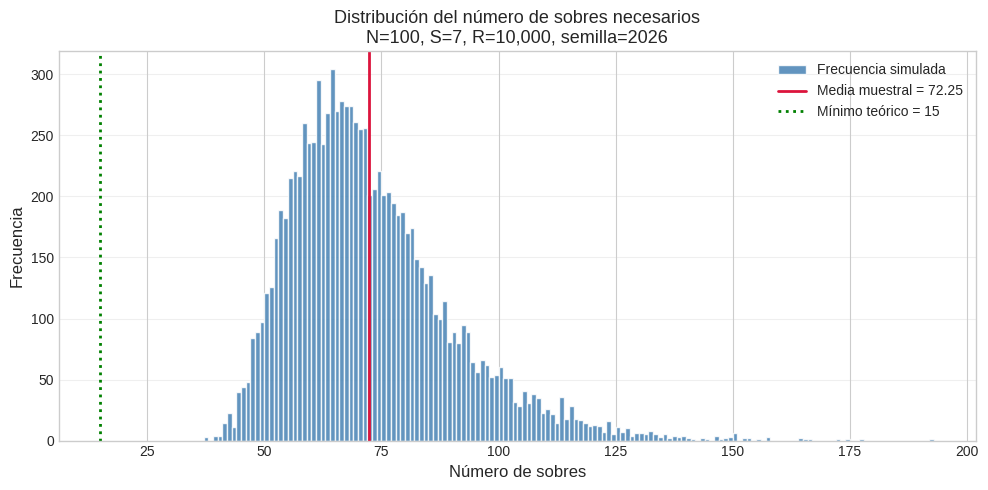

In [ ]:
"""
Laboratorio 7 — Etapa 1: Simulación básica con álbum reducido
MM3014 Teoría de Probabilidades
Universidad del Valle de Guatemala
Semilla: 2026
"""

import numpy as np
import matplotlib.pyplot as plt
import math

# ──────────────────────────────────────────────────────────
# PARÁMETROS
# ──────────────────────────────────────────────────────────
N = 100       # Número total de estampas diferentes
S = 7         # Estampas por sobre (todas distintas dentro del mismo sobre)
R = 10000     # Número de simulaciones
np.random.seed(2026)


# ──────────────────────────────────────────────────────────
# SIMULACIÓN MONTE CARLO
# ──────────────────────────────────────────────────────────
def simular_album(N, S, R):
    """Simula R veces el llenado de un álbum de N estampas con sobres de S."""
    sobres_list    = np.empty(R, dtype=int)
    repetidas_list = np.empty(R, dtype=int)

    for i in range(R):
        coleccion = set()
        sobres    = 0
        repetidas = 0

        while len(coleccion) < N:
            sobre = np.random.choice(N, S, replace=False)  # S distintas por sobre
            sobres += 1
            for e in sobre:
                if e in coleccion:
                    repetidas += 1
                else:
                    coleccion.add(e)

        sobres_list[i]    = sobres
        repetidas_list[i] = repetidas

    return sobres_list, repetidas_list


# ──────────────────────────────────────────────────────────
# CÁLCULOS TEÓRICOS
# ──────────────────────────────────────────────────────────
def calcular_teoria(N, S):
    """Calcula los valores teóricos del coupon collector problem."""
    H_N     = sum(1 / k for k in range(1, N + 1))   # Número armónico exacto
    E_T     = (N / S) * H_N                          # E[sobres] = (N/S) · H_N
    min_abs = math.ceil(N / S)                        # Mínimo absoluto sin repetidos
    E_rep   = E_T * S - N                             # E[repetidas]
    return H_N, E_T, min_abs, E_rep


# ──────────────────────────────────────────────────────────
# RESULTADOS
# ──────────────────────────────────────────────────────────
def imprimir_resultados(sobres, repetidas, H_N, E_T, min_abs, E_rep):
    media_s  = np.mean(sobres)
    std_s    = np.std(sobres)
    media_r  = np.mean(repetidas)
    std_r    = np.std(repetidas)
    prob_30  = np.mean(sobres > 30)
    min_sim  = np.min(sobres)

    print("=" * 60)
    print(" LABORATORIO 7 — Etapa 1  |  N=100, S=7, R=10 000")
    print("=" * 60)

    print("\n── Sobres necesarios ────────────────────────────────────")
    print(f"  Media             : {media_s:.4f}")
    print(f"  Desv. estándar    : {std_s:.4f}")

    print("\n── Estampas repetidas ───────────────────────────────────")
    print(f"  Media             : {media_r:.4f}")
    print(f"  Desv. estándar    : {std_r:.4f}")

    print("\n── Probabilidad ─────────────────────────────────────────")
    print(f"  P(sobres > 30)    : {prob_30:.4f}  ({prob_30*100:.2f}%)")
    print(f"  Justificación     : umbral 30 > mín. teórico {min_abs}")

    print("\n── Preguntas de análisis ────────────────────────────────")

    # Pregunta 1
    print(f"\n  1. Mínimo de sobres sin repetidos = ⌈{N}/{S}⌉ = {min_abs}")
    print(f"     Mínimo observado en simulación  = {min_sim}")
    print(f"     ¿Ocurre en simulación?          : {'Sí' if min_sim == min_abs else 'No'}")

    # Pregunta 2
    print(f"\n  2. H_{{100}} (suma exacta)      = {H_N:.6f}")
    print(f"     H_{{100}} (ln(100) + 0.5772) = {math.log(100) + 0.5772:.6f}")
    print(f"     Valor teórico E[T]         = (100/7) · H_100 = {E_T:.4f}")
    print(f"     Media simulada             = {media_s:.4f}")
    print(f"     Diferencia                 = {abs(E_T - media_s):.4f}")

    # Pregunta 3
    print(f"\n  3. E[repetidas] teórico = E[T]·S - N = {E_rep:.4f}")
    print(f"     Media simulada de repetidas     = {media_r:.4f}")
    print(f"     Diferencia                      = {abs(E_rep - media_r):.4f}")

    # Pregunta 4
    cv = std_s / media_s
    print(f"\n  4. Desv. estándar = {std_s:.4f}  |  CV = σ/μ = {cv:.4f} ({cv*100:.1f}%)")
    print(f"     Alta variabilidad: las últimas estampas son muy difíciles")
    print(f"     de obtener, generando una cola derecha larga.")


    # ── Respuestas de las preguntas de analisis
    print("\n── Respuestas ──────────────────────────────────")

    print(f"""
  Pregunta 1:
  El mínimo teórico de sobres necesarios, asumiendo que no existieran estampas
  repetidas, sería ⌈N/S⌉ = ⌈100/7⌉ = {min_abs} sobres. Sin embargo, este escenario
  es prácticamente imposible: en las {R:,} simulaciones realizadas, el mínimo
  observado fue {min_sim} sobres, y ninguna simulación alcanzó el mínimo teórico.
  Esto confirma que las repeticiones son inevitables en la práctica.

  Pregunta 2:
  Usando la teoría del coleccionista con S={S} estampas por sobre, el valor
  esperado teórico es E[T] = (N/S)·H_N = (100/7)·{H_N:.4f} = {E_T:.4f} sobres.
  La media obtenida en simulación fue {media_s:.4f} sobres, con una diferencia de
  apenas {abs(E_T - media_s):.4f} sobres respecto al valor teórico. Esto valida
  que la simulación Monte Carlo converge correctamente a la predicción teórica.

  Pregunta 3:
  El valor esperado teórico de estampas repetidas es E[rep] = E[T]·S - N =
  {E_T:.4f}·{S} - {N} = {E_rep:.4f}. La simulación arrojó una media de {media_r:.4f}
  repetidas, una diferencia de {abs(E_rep - media_r):.4f}. Nuevamente, la teoría
  y la simulación están muy alineadas.

  Pregunta 4:
  La desviación estándar del número de sobres es {std_s:.4f}, lo que representa
  un coeficiente de variación de {cv*100:.1f}% respecto a la media. Esta alta
  variabilidad es característica del problema del coleccionista: al inicio del
  llenado casi cualquier estampa es nueva, por lo que se avanza rápido; pero
  conforme el álbum se llena, la probabilidad de obtener una estampa que falta
  disminuye, haciendo que las últimas estampas sean extremadamente difíciles de
  conseguir. Esto genera una distribución con cola derecha larga y, por tanto,
  una varianza elevada.
""")
    return media_s


# ──────────────────────────────────────────────────────────
# HISTOGRAMA
# ──────────────────────────────────────────────────────────
def graficar_histograma(sobres, media_s, E_T, min_abs):
    """Histograma de frecuencias del número de sobres necesarios."""
    bins = range(sobres.min(), sobres.max() + 2)   # bins enteros discretos

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.hist(sobres, bins=bins, color='steelblue', edgecolor='white',
            alpha=0.85, label='Frecuencia simulada')

    ax.axvline(media_s, color='crimson', linewidth=2,
               label=f'Media muestral = {media_s:.2f}')
    ax.axvline(min_abs, color='green', linewidth=2, linestyle=':',
               label=f'Mínimo teórico = {min_abs}')

    ax.set_title('Distribución del número de sobres necesarios\n'
                 f'N={N}, S={S}, R={R:,}, semilla=2026', fontsize=13)
    ax.set_xlabel('Número de sobres', fontsize=12)
    ax.set_ylabel('Frecuencia', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


# ──────────────────────────────────────────────────────────
# MAIN
# ──────────────────────────────────────────────────────────
if __name__ == "__main__":
    sobres, repetidas        = simular_album(N, S, R)
    H_N, E_T, min_abs, E_rep = calcular_teoria(N, S)
    media_s                  = imprimir_resultados(sobres, repetidas,
                                                   H_N, E_T, min_abs, E_rep)
    graficar_histograma(sobres, media_s, E_T, min_abs)


# Etapa 2

M = 20 sobres → P(completar) = 0.0000
M = 25 sobres → P(completar) = 0.0000
M = 30 sobres → P(completar) = 0.0000
M = 35 sobres → P(completar) = 0.0000
M = 40 sobres → P(completar) = 0.0019
M = 45 sobres → P(completar) = 0.0143
M = 50 sobres → P(completar) = 0.0571
M = 60 sobres → P(completar) = 0.2723
M = 70 sobres → P(completar) = 0.5340
M = 80 sobres → P(completar) = 0.7393


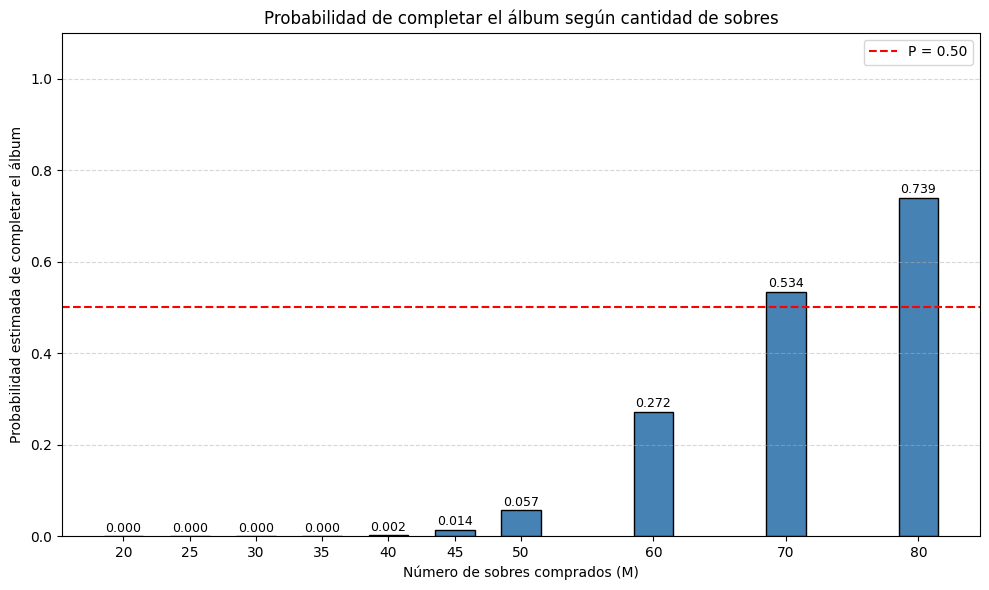


Pregunta 1:
  El álbum se completa con probabilidad ≥ 50% a partir de M = 70 sobres
  El álbum se completa con probabilidad ≥ 90% a partir de M = None sobres

Pregunta 2:
  M con probabilidad ≈ 50% (Etapa 2): 70 sobres
  Mediana de sobres necesarios (Etapa 1): 72 sobres
  Son valores similares porque ambos representan el punto medio:
  la cantidad de sobres donde la mitad de las simulaciones logran completar el álbum.

Pregunta 3:
  Para M = 50 sobres:
  P(falta una estampa específica) = 0.030197
  Cota superior P(falta al menos 1) ≤ 100 × 0.030197 = 3.0197
  → Cota inferior para P(éxito) = 1 - 3.0197 = -2.0197
  Probabilidad simulada para M = 50: 0.0571
  La cota NO ES útil: supera 1, así que no aporta información útil.


In [10]:
# Semilla para reproducibilidad
np.random.seed(2026)

# Parámetros
N = 100   # total de estampas distintas en el álbum
S = 7     # estampas por sobre
R = 10000 # número de simulaciones

# Secuencia de valores de M a probar
num_sobres = [20, 25, 30, 35, 40, 45, 50, 60, 70, 80]
probabilidades = []

# Para cada valor de M simulamos R veces y registramos si el álbum quedó completo
for M in num_sobres:
    resultados = []

    for i in range(R):
        estampas_obtenidas = []

        for j in range(M):
            sobre = np.random.choice(N, size=S, replace=False)
            estampas_obtenidas.append(sobre)

        estampas_obtenidas = np.concatenate(estampas_obtenidas)

        if len(np.unique(estampas_obtenidas)) == N:
            album_completo = 1
        else:
            album_completo = 0

        resultados.append(album_completo)

    probabilidad = np.mean(resultados)
    probabilidades.append(probabilidad)
    print(f"M = {M} sobres → P(completar) = {probabilidad:.4f}")


# VISUALIZACIÓN

plt.figure(figsize=(10, 6))
plt.bar(num_sobres, probabilidades, width=3, color='steelblue', edgecolor='black')
plt.axhline(y=0.5, color='red', linestyle='--', label='P = 0.50')


for i in range(len(num_sobres)):
    plt.text(num_sobres[i], probabilidades[i] + 0.01,
             f'{probabilidades[i]:.3f}', ha='center', fontsize=9)

plt.xlabel('Número de sobres comprados (M)')
plt.ylabel('Probabilidad estimada de completar el álbum')
plt.title('Probabilidad de completar el álbum según cantidad de sobres')
plt.xticks(num_sobres)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# Pregunta 1

M_50 = None
M_90 = None

for i in range(len(num_sobres)):
    if probabilidades[i] >= 0.50 and M_50 is None:
        M_50 = num_sobres[i]
    if probabilidades[i] >= 0.90 and M_90 is None:
        M_90 = num_sobres[i]

print(f"\nPregunta 1:")
print(f"  El álbum se completa con probabilidad ≥ 50% a partir de M = {M_50} sobres")
print(f"  El álbum se completa con probabilidad ≥ 90% a partir de M = {M_90} sobres")


# Pregunta 2

mediana_etapa1 = 72

print(f"\nPregunta 2:")
print(f"  M con probabilidad ≈ 50% (Etapa 2): {M_50} sobres")
print(f"  Mediana de sobres necesarios (Etapa 1): {mediana_etapa1} sobres")
print(f"  Son valores similares porque ambos representan el punto medio:")
print(f"  la cantidad de sobres donde la mitad de las simulaciones logran completar el álbum.")


# Pregunta 3

M_eval = 50

# La probabilidad de NO obtener una estampa específica después de M sobres es aprox. e^(-M*S/N)
prob_falta_una = np.exp(-M_eval * S / N)

# Por la desigualdad de la unión
cota_falla = N * prob_falta_una

# Por complemento
cota_exito = 1 - cota_falla

# Probabilidad simulada para M = 50
prob_simulada_50 = probabilidades[num_sobres.index(50)]

print(f"\nPregunta 3:")
print(f"  Para M = {M_eval} sobres:")
print(f"  P(falta una estampa específica) = {prob_falta_una:.6f}")
print(f"  Cota superior P(falta al menos 1) ≤ {N} × {prob_falta_una:.6f} = {cota_falla:.4f}")
print(f"  → Cota inferior para P(éxito) = 1 - {cota_falla:.4f} = {cota_exito:.4f}")
print(f"  Probabilidad simulada para M = 50: {prob_simulada_50:.4f}")
print(f"  La cota {'ES' if 0 <= cota_falla <= 1 else 'NO ES'} útil: ", end="")
if 0 <= cota_falla <= 1:
    print("acota correctamente la probabilidad, aunque es conservadora.")
else:
    print("supera 1, así que no aporta información útil.")

